# **Airbnb Market Analysis and Pricing Intelligence for Property Managers**

## Business Objective


Property owners often face challenges in determining the optimal price for their properties due to differences in location, room type, availability, and reviews.

This analysis is conducted from the perspective of a property management company seeking to better understand pricing dynamics, demand patterns, and market opportunities across New York City's short-term rental market.



In [2]:
import pandas as pd
from datasets import load_dataset 
import matplotlib.pyplot as plt 
#loading dataset 
import ast
import numpy as np
#loading the dataset
df=pd.read_csv("Airbnb_project.csv")
import seaborn as sb

## Dataset Overview

The dataset contains Airbnb listings and includes information about pricing, location, room type, reviews, host activity, and availability. 

In [3]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


## Data Cleaning and Missing Values
First inspected the dataset for missing values and data quality issues.I found that many listings had null values in the last_review column and reviews_per_month. This indicates that those listings likely never received reviews, meaning they may have zero customer engagement.

In [4]:
# replacing null values for the reviews_per_month with 0.
df['reviews_per_month'].fillna(0,inplace=True)

#df[df.isnull().any(axis=1)]

C:\Users\shaza\AppData\Local\Temp\ipykernel_22968\1617071902.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0,inplace=True)


In [5]:
df.isnull().sum()


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
# converting last review object to the datetime
df['last_review']=pd.to_datetime(df['last_review'])


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

In [9]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.090910,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.597283,32.952519,131.622289


In [10]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [11]:
# Created this column to identify whether a listing has received at least one customer review
df["has_review"]=df['number_of_reviews']>0

In [12]:
df[['number_of_reviews','has_review']]

,number_of_reviews,has_review
0,9,True
1,45,True
2,0,False
3,270,True
4,9,True
...,...,...
48890,0,False
48891,0,False
48892,0,False
48893,0,False


In [13]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,True
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,True
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,False
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,True
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaT,0.00,2,9,False
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaT,0.00,2,36,False
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,0.00,1,27,False
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaT,0.00,6,2,False


In [14]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.090910,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.597283,32.952519,131.622289


In [15]:
#I categorized listings into different price groups to understand how customer demand changes across budget levels. 
# This helps identify which type of listings customers prefer more.
df['price_category']=pd.cut(df["price"],bins=[0,50,100,200,400,800],labels=["Budget","Standard","Premium","High","Luxury"])

In [16]:
df["price_category"].value_counts()

price_category
Standard    17367
Premium     16583
High         6621
Budget       6550
Luxury       1343
Name: count, dtype: int64

In [17]:
(df["price"]<500).sum()

np.int64(47660)

# Outlier Detection and Price Distribution

Text(0, 0.5, 'Number of Listings')

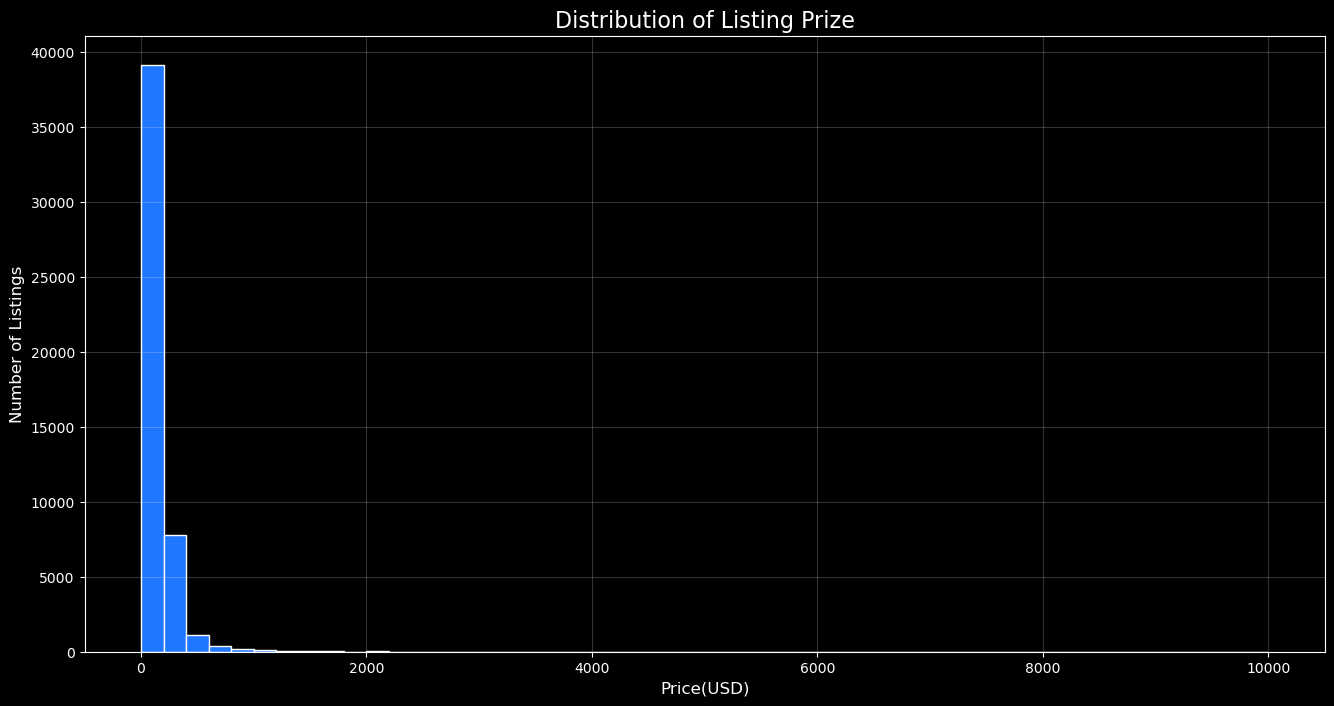

In [18]:
plt.style.use("dark_background")

plt.figure(figsize=(16,8))
plt.title("Distribution of Listing Prize",
          fontsize=16,
          color="white")

plt.hist(df['price'],bins=50,color="#1f77ff",edgecolor="white")
plt.grid(alpha=0.2,color="white")
plt.xlabel("Price(USD)",fontsize=12)
plt.ylabel("Number of Listings",fontsize=12)


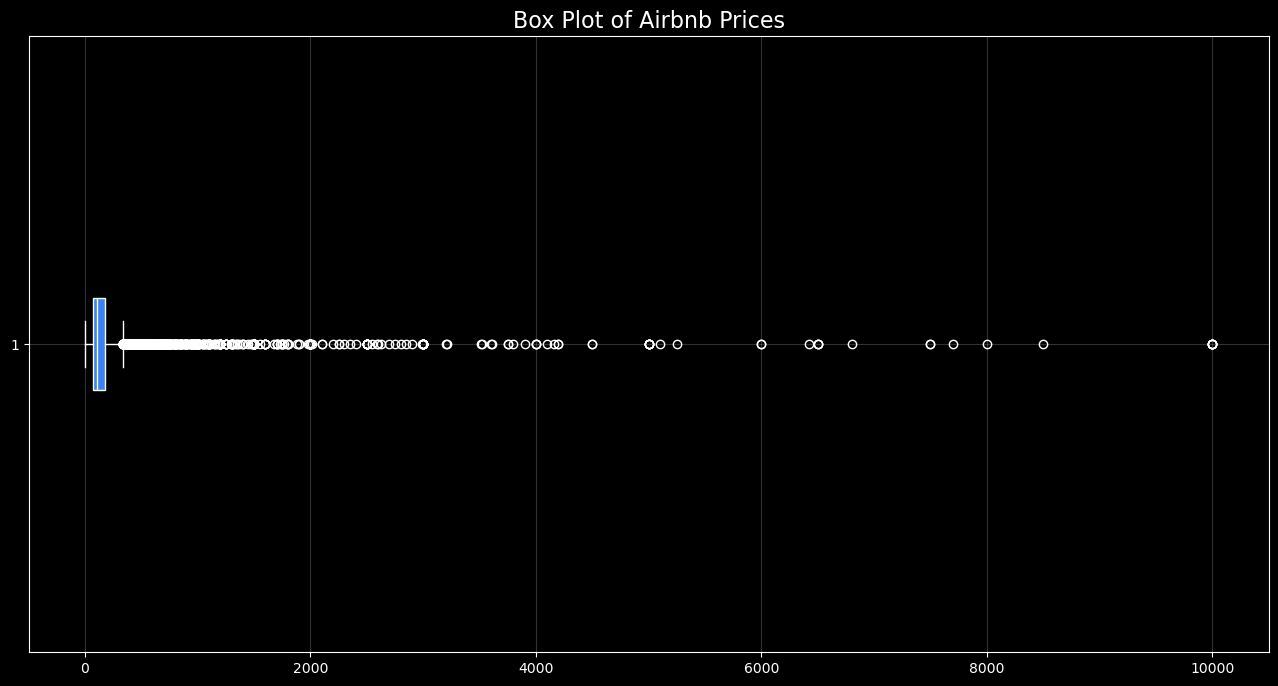

In [19]:
plt.figure(figsize=(16,8))
plt.boxplot(
    df["price"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#3B82F6",color="white")
)

plt.grid(alpha=0.2,color="white")
plt.title("Box Plot of Airbnb Prices",fontsize=16,color="white")
plt.show()


**=>Important** The graphs show that Airbnb prices are highly right-skewed, where most listings fall within the lower price range while a few listings have extremely high prices. This indicates the presence of outliers in the dataset.

In [20]:
print("Original Mean",df['price'].mean())
print("original Median",df["price"].median())


Original Mean 152.7206871868289
original Median 106.0


Mean >Median so means that small number of listings are pulling the avg upward.The largt gap indicate a right skewed data. 

In [21]:
#using quarantine method
upper_limit=df['price'].quantile(0.99)
upper_limit

np.float64(799.0)

In [22]:
df_filtered=df[df['price']<=upper_limit]

In [23]:
print("Filtered Mean:", df_filtered["price"].mean())
print("Filtered Median:", df_filtered["price"].median())

Filtered Mean: 137.54391689556184
Filtered Median: 105.0


**After filtering, the mean price decreased from $152.7 to $137.6, while the median remained stable.**

Since Airbnb prices were heavily right-skewed, the 99th percentile method was used to handle extreme outliers. This retained 99% of listings while removing only the most expensive 1% that affected average prices, resulting in a more representative dataset for analysis

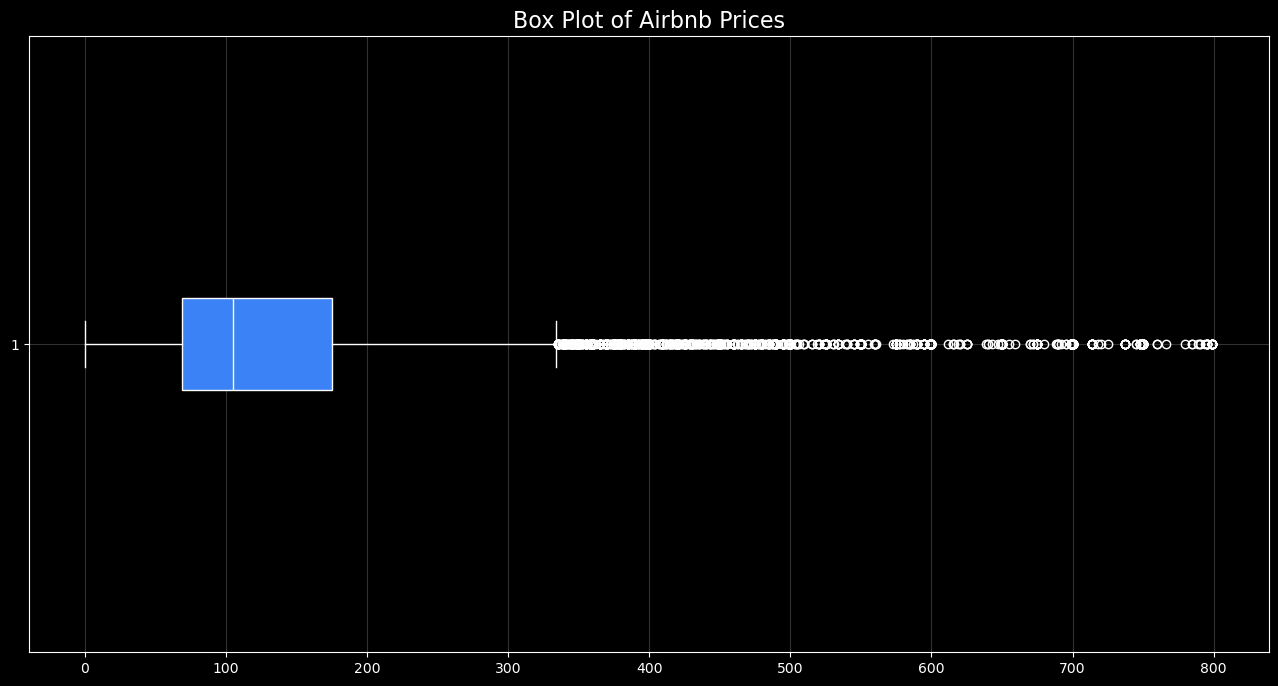

In [24]:
plt.figure(figsize=(16,8))
plt.boxplot(
    df_filtered["price"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#3B82F6",color="white")
)

plt.grid(alpha=0.2,color="white")
plt.title("Box Plot of Airbnb Prices",fontsize=16,color="white")
plt.show()


### **Insights**: The 99th percentile filtering successfully reduced the impact of extreme price outliers while retaining realistic high-value listings. Some outliers remain, but they now have a much smaller influence

In [25]:
#dropping the data which has no price for the listing.
df_filtered=df_filtered[df_filtered["price"]>0]
df_filtered["price"].max()

799

# **How is the Airbnb market segmented by listing price?**
I first analyze how listing prices are distributed accross the dataset

Text(0, 0.5, 'Frequency')

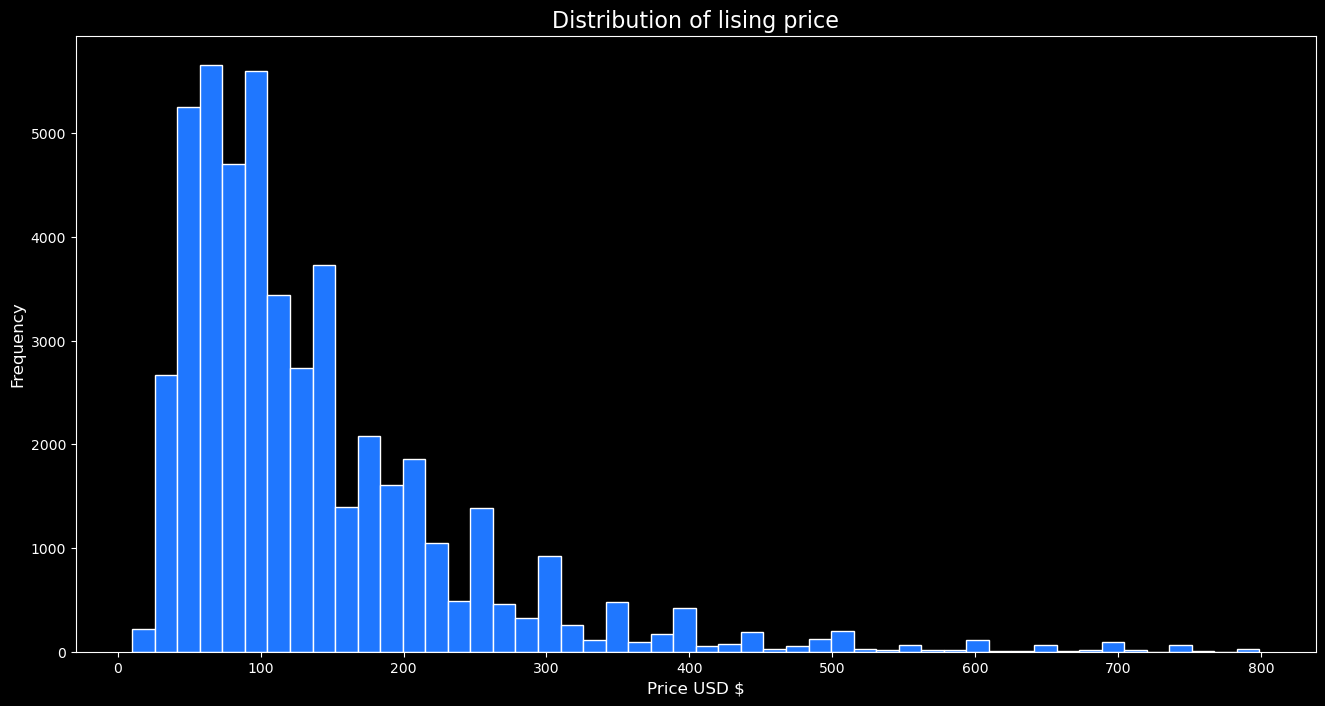

In [26]:
plt.figure(figsize=(16,8))
plt.hist(df_filtered['price'],bins=50,color="#1f77ff",edgecolor="white")
plt.title("Distribution of lising price",fontsize=16)
plt.xlabel("Price USD $",fontsize=12)
plt.ylabel("Frequency",fontsize=12)

### **Insight**: The distribution of the listing prices is right-skewed. Most of the listings falls between 50 and 200$, indicating a strong concentration in the mid-price range. 

In [27]:
df_price_dist=df_filtered.groupby("price_category").agg(
    listings=("id","count"))
df_price_dist
df_price_dist["pct"]=(df_price_dist["listings"]/df_price_dist["listings"].sum()*100).round(2)
df_price_dist.sort_values(by="listings",ascending=False,inplace=True)
df_price_dist

C:\Users\shaza\AppData\Local\Temp\ipykernel_22968\3283584286.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_price_dist=df_filtered.groupby("price_category").agg(


,listings,pct
price_category,,
Standard,17367,35.87
Premium,16583,34.26
High,6621,13.68
Budget,6550,13.53
Luxury,1289,2.66


C:\Users\shaza\AppData\Local\Temp\ipykernel_22968\2793114988.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart=sb.barplot(x=df_price_dist.index,y=df_price_dist["listings"].values,order=df_price_dist.index,palette="crest")


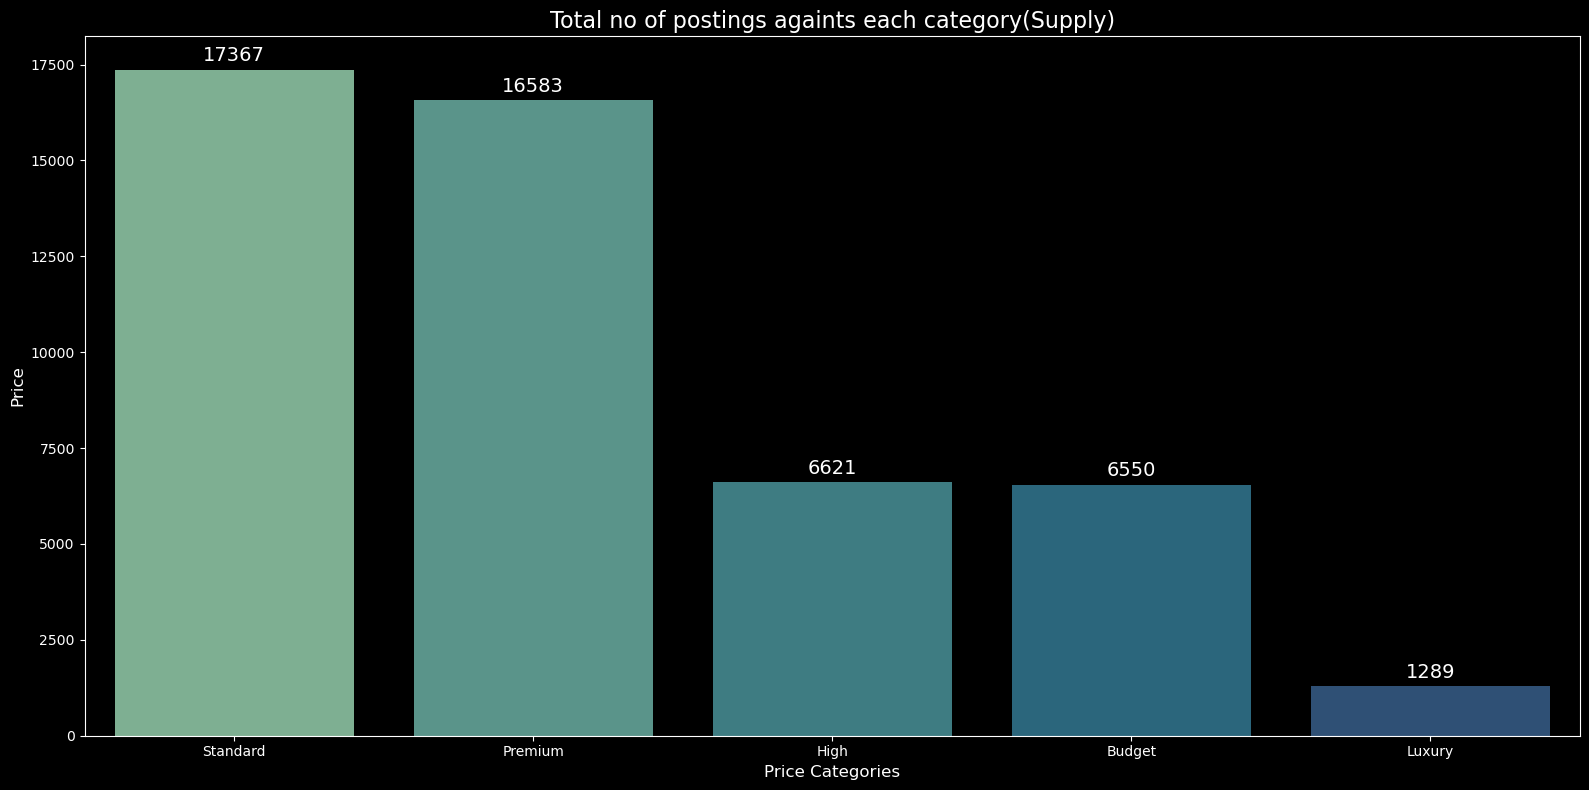

In [28]:
plt.figure(figsize=(16,8))


plt.title("Total no of postings againts each category(Supply)",fontsize=16)
plt.xlabel("Price Categories",fontsize=12)
plt.ylabel("Price",fontsize=12)
chart=sb.barplot(x=df_price_dist.index,y=df_price_dist["listings"].values,order=df_price_dist.index,palette="crest")


plt.tight_layout()
for container in chart.containers:
    chart.bar_label(container,fmt="%d",padding=3,fontsize=14)
plt.show()    

### **Insight**: The short term rental market is primarily concentrated within the Standard and Premium price segments which accounts 69% together. Luxury listings represent only a small portion of the marketplace. The concentration of listings within the Standard and Premium segments indicates intense competition in these markets. *Hosts operating in these segments may need to differentiate through location, amenities, and guest experience(reviews).* 

## **Which neighborhoods command premium pricing?**



Management team must wants to understand location-based pricing power.
They want to know which markets support premium pricing.
Investors want to identify high-value areas.

Text(0.5, 1.0, 'Price Distribution Across NYC Boroughs')

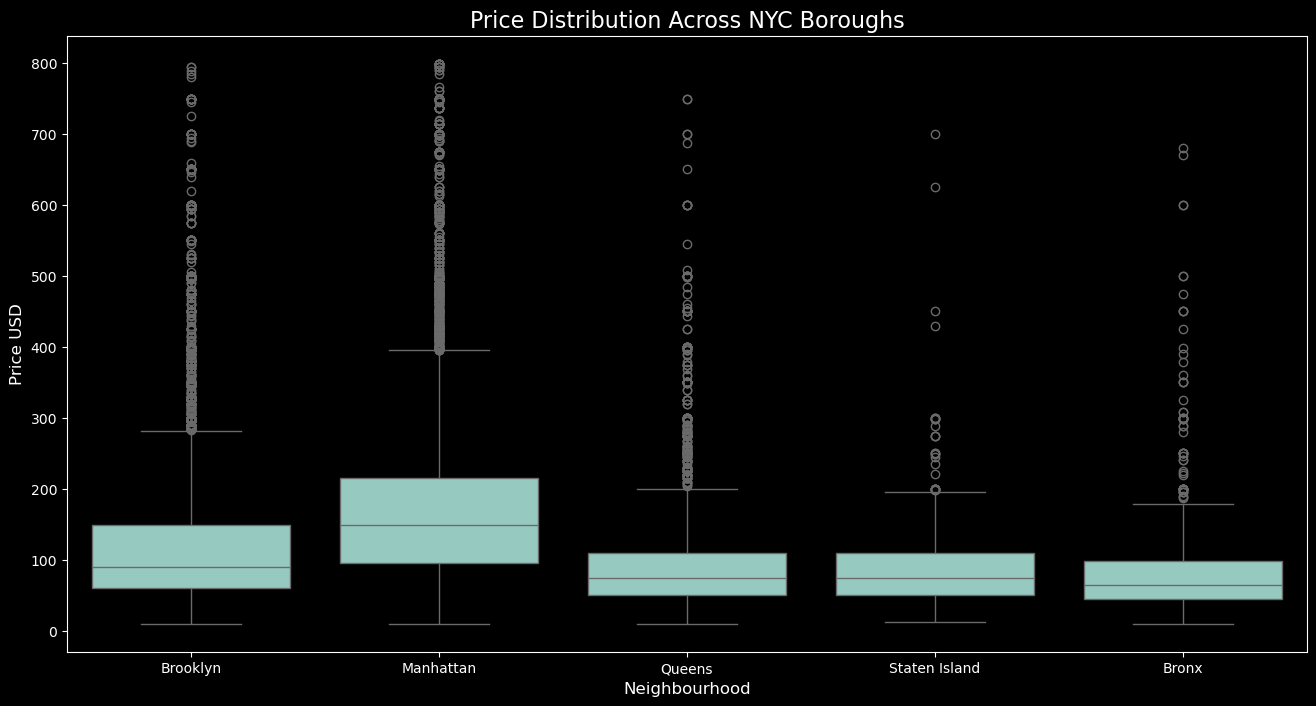

In [29]:
plt.figure(figsize=(16,8))
df_filtered.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False)
sb.boxplot(
    data=df_filtered,
    x="neighbourhood_group",
    y="price"
    
    
)
plt.xlabel("Neighbourhood",fontsize=12)
plt.ylabel("Price USD",fontsize=12)
plt.title("Price Distribution Across NYC Boroughs",fontsize=16)

### **Insight2**: Manhattan exhibits the highest median listing price among all boroughs. While most listings are concentrated between $100 and $200 per night, the borough also contains a good number of high-priced listings ranging from $400 to $800, indicating a strong premium and luxury market segment. They may have greater flexibility to implement higher pricing strategies and maximize revenue potential

## **Which neighbourhoods demonstrate the strongest demand?**
Airbnb does not provide actual booking or occupancy data in this dataset. Therefore, reviews_per_month is used as a proxy for demand 

In [30]:
df_rpm=df_filtered["reviews_per_month"].describe()
df_rpm



count    48410.000000
mean         1.096716
std          1.601074
min          0.000000
25%          0.040000
50%          0.380000
75%          1.600000
max         58.500000
Name: reviews_per_month, dtype: float64

In [84]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()


data_neigh_rpm=df_filtered.groupby("neighbourhood_group").agg(
       total_listings=("number_of_reviews","count"),
       avg_rpm=("reviews_per_month","mean"),
       total_reviews=("number_of_reviews","sum"),
       avg_price=("price","mean")
       )
data_neigh_rpm[["price_score","rpm_score","listings_score"]]=scaler.fit_transform(data_neigh_rpm[["avg_price","avg_rpm","total_listings"]])
data_neigh_rpm.sort_values(by="avg_rpm",ascending=False)
data_neigh_rpm["market_opportunity_score"]=(data_neigh_rpm["price_score"]*0.4+data_neigh_rpm["rpm_score"]*0.3+data_neigh_rpm["listings_score"]*0.3)
data_neigh_rpm

,total_listings,avg_rpm,total_reviews,avg_price,price_score,rpm_score,listings_score,market_opportunity_score
neighbourhood_group,,,,,,,,
Bronx,1087,1.478694,28315,83.862925,0.000000,0.811637,0.034284,0.253776
Brooklyn,19992,1.052985,485138,115.921519,0.360051,0.112985,0.936972,0.459007
Manhattan,21312,0.984140,451606,172.901886,1.000000,0.000000,1.000000,0.700000
Queens,5650,1.570168,156807,94.104779,0.115027,0.961760,0.252161,0.410187
Staten Island,369,1.593469,11541,94.241192,0.116559,1.000000,0.000000,0.346623


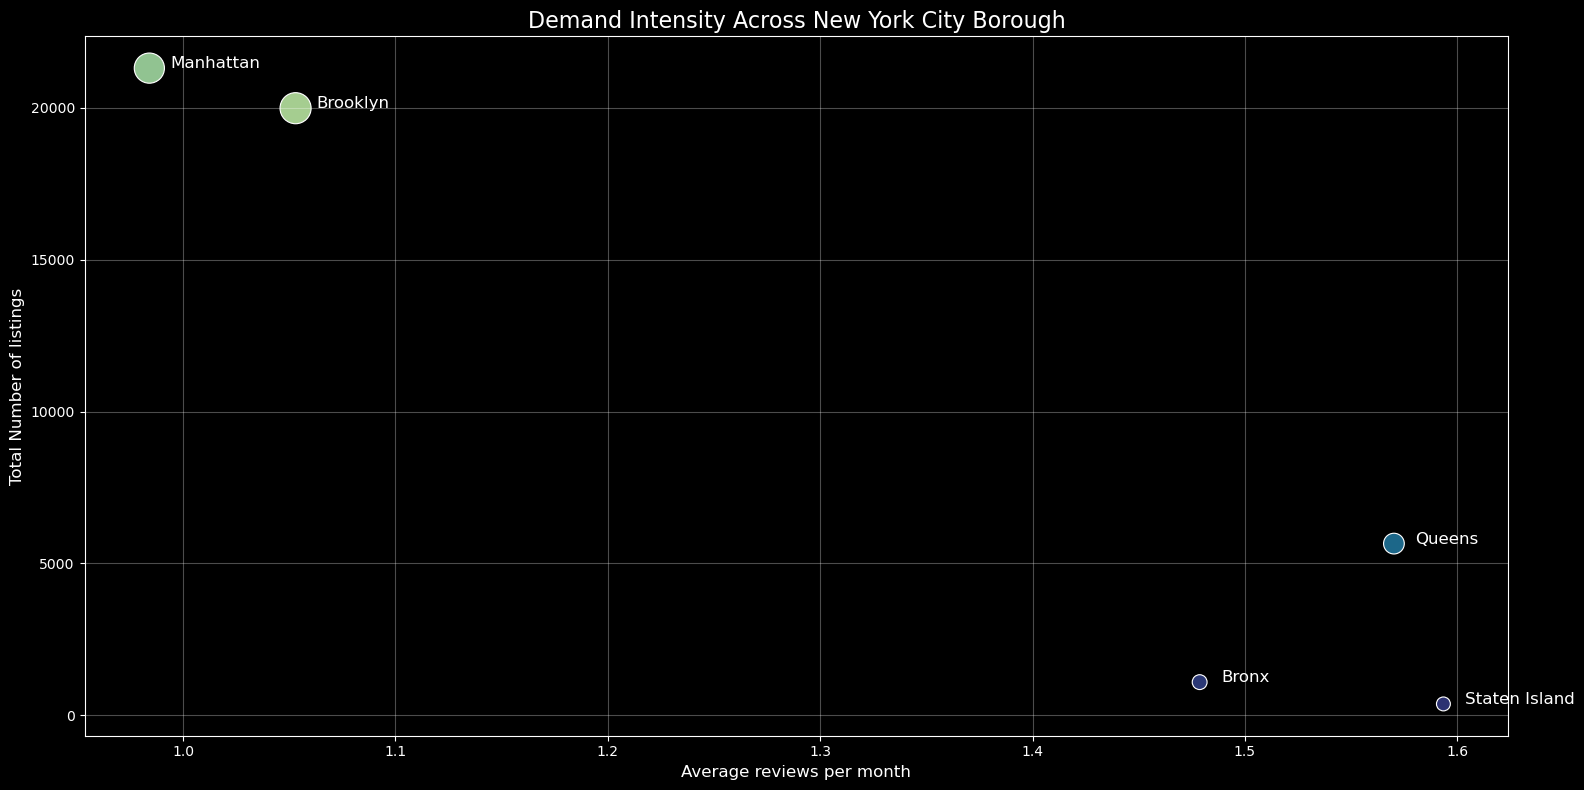

In [32]:
plt.figure(figsize=(16,8))
sb.scatterplot(
    data=data_neigh_rpm,
    x="avg_rpm",
    y="total_listings",
    size="total_reviews",
    sizes=(100,500),
    hue="total_reviews",
    palette="crest_r"
  
)
plt.legend().set_visible(False)
for i,grp in enumerate(data_neigh_rpm.index):
    plt.text(
        data_neigh_rpm["avg_rpm"].iloc[i]+0.01,
        data_neigh_rpm["total_listings"].iloc[i],
        grp,
        fontsize=12
    )
plt.grid(alpha=0.3)
plt.ylabel("Total Number of listings",fontsize=12)
plt.xlabel("Average reviews per month",fontsize=12)
plt.title("Demand Intensity Across New York City Borough",fontsize=16)
plt.tight_layout()      

### **Insights**: This is the interesting fact here. Based on reviews per month as a proxy for demand, Staten Island, Bronx, and Queens demonstrate the highest review activity per month. Manhattan, despite commanding the highest prices, second most number of listings, exhibits lower review activity per month, suggesting that its premium pricing may be associated with lower booking frequency compared to more affordable boroughs.

### **Business insights**: For the property owners seeking higher booking activity,  Staten Island and Bronx may present attractive opportunities due to their strong demand signals and lower price levels compared to Manhattan. While Manhattan remains the premium marketplace because of the higher avg price, it also has highest number of listings, resulting in greater competition among hosts. 

## **Which price segments are driving demand and supply within high-opportunity neighbourhoods?"**
Previous Analysis shows that the neighbourhoods differ significantly in pricing, demand and listing supply. For example, Stalen Island demostrated high review activity but it also had lesser listings. To understand these patterns, we need to examine how price categories(premium,high,standard,luxury) contributes towards listings and customer engagement in each neighbourhood.

In [33]:
df_neigh_data=df_filtered.groupby(["neighbourhood_group","price_category"]).size().unstack()
df_neigh_data

C:\Users\shaza\AppData\Local\Temp\ipykernel_22968\2531069223.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_neigh_data=df_filtered.groupby(["neighbourhood_group","price_category"]).size().unstack()


price_category,Budget,Standard,Premium,High,Luxury
neighbourhood_group,,,,,
Bronx,371,493,181,31,11
Brooklyn,3572,8190,6278,1663,289
Manhattan,1035,5885,8803,4642,947
Queens,1468,2633,1243,268,38
Staten Island,104,166,78,17,4


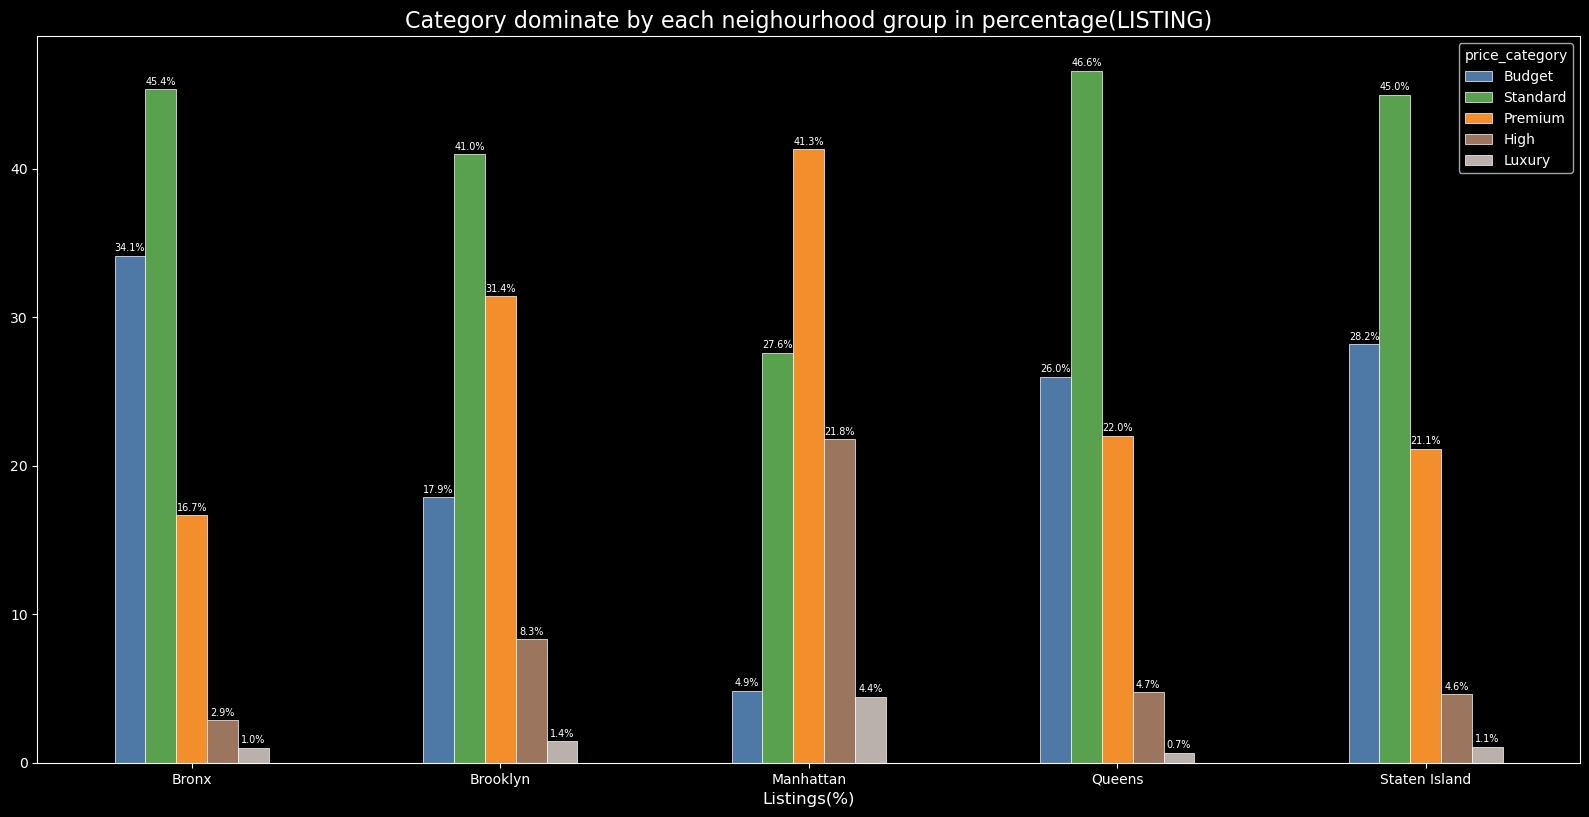

In [34]:

colors = [
   "#4E79A7",  # Budget - Blue
    "#59A14F",  # Standard - Green
    "#F28E2B",  # Premium - Orange
    "#9C755F",  # High - Brown
    "#BAB0AC"   # Luxury
]
df_percent=df_neigh_data.div(df_neigh_data.sum(axis=1),axis=0)*100
chart=df_percent.plot(kind="bar", figsize=(16,8),color=colors,edgecolor="white",linewidth=0.5)
for p in chart.containers:
    chart.bar_label(p,fmt='%.1f%%', padding=2,fontsize=7)
plt.xticks(rotation=360)
plt.tight_layout()
plt.title('Category dominate by each neighourhood group in percentage(LISTING)',fontsize=16)
plt.xlabel("Neighbourhood",fontsize=12)
plt.xlabel("Listings(%)",fontsize=12)
plt.show()

### **Insights**: Most neighbourhoods are dominated by the standard and premium listings, showing the mid range options are the most common. Manhattan has more high prices listings because budget listings goes down and there was an increase in premium, high and luxury listigs as compared to other areas. Bronx, queen and staten island focus more on affordable options like budget and Standard.

### **Business Recommendation:** Based on the listings, In manhattan, Premium and high ending listings are well supported accounted 63%, making it best option for high revenue per booking. However, for Stalen, Bronx and Queens, Standard and Budget dominated, indicating stronger opportunities for value focused listings.   

## **Do customer demand patterns allign with the existing supply distribution across price segments?**

C:\Users\shaza\AppData\Local\Temp\ipykernel_22968\3308925627.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot=pd.pivot_table(data=df_filtered,


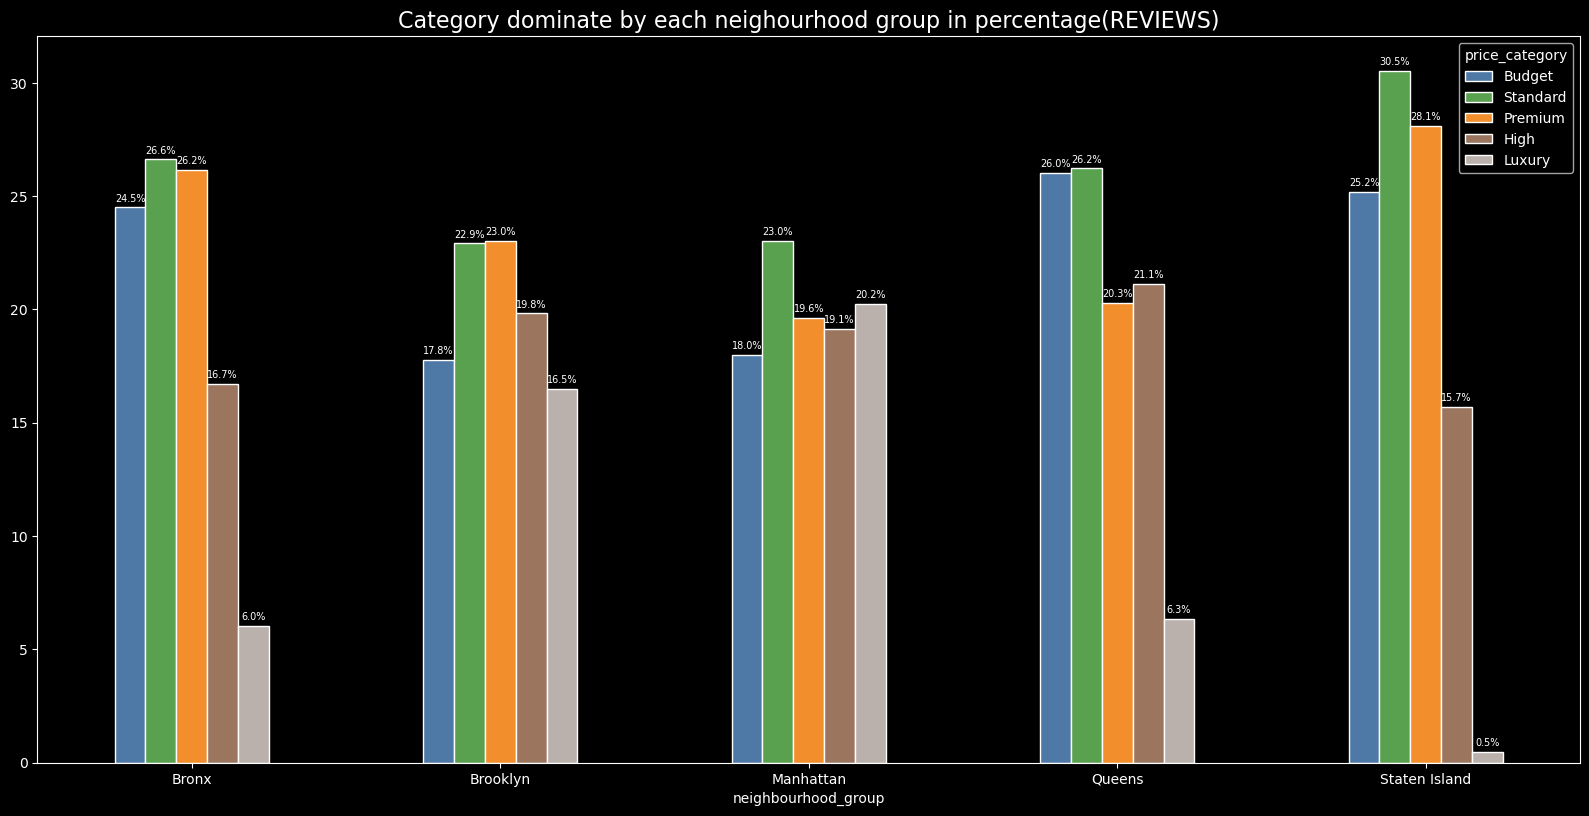

In [35]:
colors = [
   "#4E79A7",  # Budget - Blue
    "#59A14F",  # Standard - Green
    "#F28E2B",  # Premium - Orange
    "#9C755F",  # High - Brown
    "#BAB0AC"   # Luxury
]

df_pivot=pd.pivot_table(data=df_filtered,
                        index="neighbourhood_group",
                        columns="price_category",
                        values="reviews_per_month",
                        aggfunc="mean")

df_percent=df_pivot.div(df_pivot.sum(axis=1),axis=0)*100
df_percent
chart=df_percent.plot(kind="bar",  figsize=(16,8),color=colors, edgecolor="white")
for p in chart.containers:
      chart.bar_label(p,fmt='%.1f%%', padding=3, fontsize=7)
plt.xticks(rotation=360)
plt.tight_layout()
plt.title('Category dominate by each neighourhood group in percentage(REVIEWS)',fontsize=16)
plt.show()


### **Insights:**  Staten Island shows strong demand despite having fewer listings, we can see that Standard and Premium segments contributes to  the majority of customer engagement across most neighbourhoods. Manhattan remains the strongest market for higher-priced categories like Luxury listings.

 


## Market Opportunity Score

To support investment decisions, a Market Opportunity Score was developed to rank each borough based on its overall business potential. The score combines three key performance indicators:

Average Price (40%) – Represents revenue potential.
Reviews per Month (30%) – Used as a proxy for customer demand.
Total Listings (30%) – Represents market size.

In [85]:
data_neigh_rpm["market_opportunity_score"].sort_values(ascending=False)

neighbourhood_group
Manhattan        0.700000
Brooklyn         0.459007
Queens           0.410187
Staten Island    0.346623
Bronx            0.253776
Name: market_opportunity_score, dtype: float64

### The Market Opportunity Score identified **Manhattan** as the strongest investment opportunity due to its combination of premium pricing and the largest market size. Brooklyn ranked second because of its extensive inventory, while Queens demonstrated strong demand but a comparatively smaller market. Although Staten Island recorded the highest customer demand, its limited inventory reduced its overall investment score, suggesting an emerging growth opportunity rather than an immediate expansion target.

## **Drilling Down from Boroughs to Neighbourhoods**
### Which specific neighbourhoods within **Manhattan** are driving this premium market?
Previous analysis identified Manhattan as New York City's premium market region. To uncover the drivers behind this performance, we drill down into individual Manhattan neighbourhoods and identify the areas that combine premium pricing, strong demand, and sufficient market size.

In [36]:
data_manhattan=df_filtered[df_filtered["neighbourhood_group"]=="Manhattan"]
df_manhattan=data_manhattan.groupby("neighbourhood").agg(
    avg_price=("price","mean"),
    listing_count=("price","count"),
    avg_reviews=("reviews_per_month","mean")

).round(2)


manhattan_top10=df_manhattan[df_manhattan["listing_count"]>100].sort_values(by="avg_price",ascending=False).head(10)
manhattan_top10
# Keep neighborhoods with at least 100 listings to focus on


,avg_price,listing_count,avg_reviews
neighbourhood,,,
Tribeca,295.65,156,0.57
Midtown,255.75,1503,0.82
SoHo,229.83,337,0.93
West Village,224.90,738,0.75
Financial District,215.75,738,1.02
Theater District,214.23,279,1.33
Chelsea,212.74,1084,0.95
Murray Hill,210.23,478,0.64
Greenwich Village,206.09,379,0.73


Text(0.5, 1.0, 'Premium Market Opportuities in Manhattan')

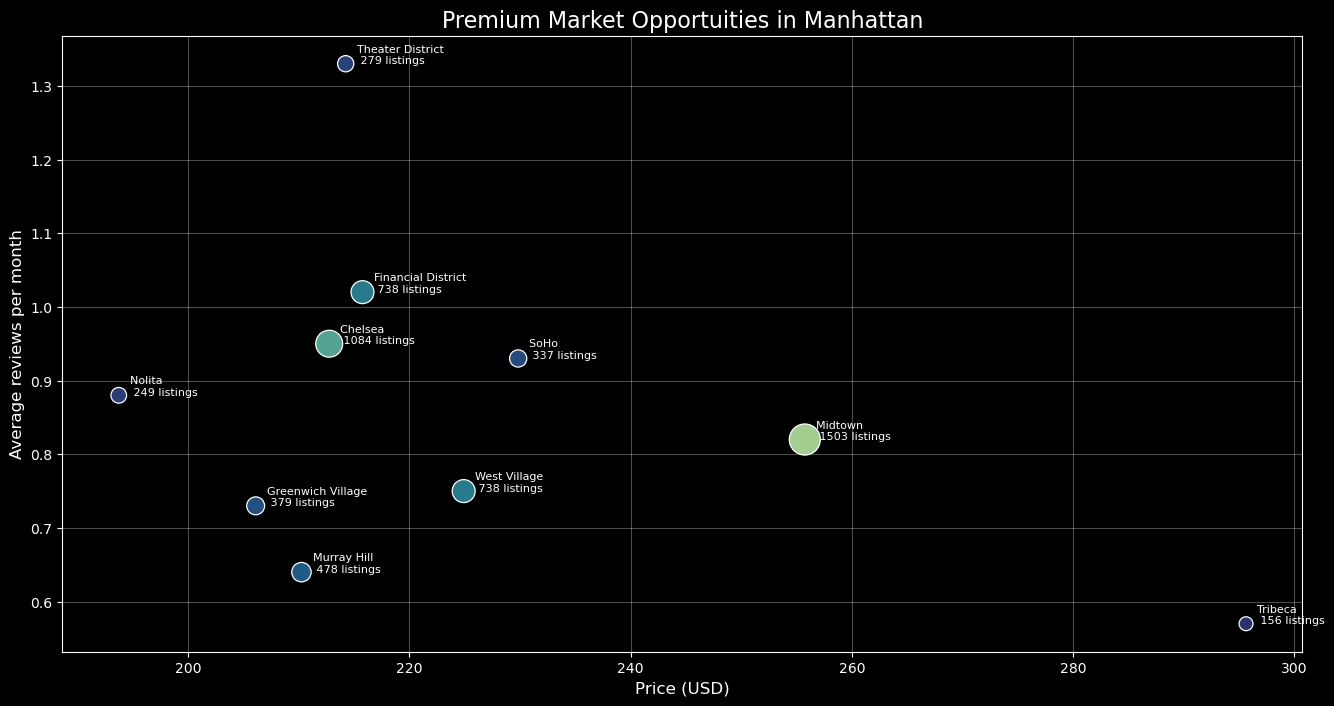

In [37]:
plt.figure(figsize=(16,8))
sb.scatterplot(data=manhattan_top10,
               size="listing_count",
               x="avg_price",
               y="avg_reviews",
               hue="listing_count",
                palette="crest_r",
                sizes=(100,500)
              
)   
plt.legend().set_visible(False)
for i,item in enumerate(manhattan_top10.index):
    plt.text(manhattan_top10["avg_price"].iloc[i]+1,
             manhattan_top10["avg_reviews"].iloc[i],
              f"{manhattan_top10.index[i]} \n {manhattan_top10["listing_count"].iloc[i]} listings",fontsize=8)
plt.grid(alpha=0.3)    
plt.xlabel("Price (USD)",fontsize=12)    
plt.ylabel("Average reviews per month", fontsize=12)
plt.title("Premium Market Opportuities in Manhattan",fontsize=16)

### **Insights** While Tribeca holds the premium pricing with lower review activity and less listings, Financial District, Chelsea and Midtown commands the balance betweem pricing,inventory and customer engagement. While neighborhoods such as West Village and Murray Hill maintain moderate pricing, they generate comparatively lower review activity, suggesting lower guest engagement than the leading markets.

### **Business Recommendation**: Prioritze expansion in Midtown, Chelsea and Financial District, where premium pricing is supported by strong demand and large market size, while treating Tribeca as a niche 

In [38]:
summary=manhattan_top10.copy()
summary

,avg_price,listing_count,avg_reviews
neighbourhood,,,
Tribeca,295.65,156,0.57
Midtown,255.75,1503,0.82
SoHo,229.83,337,0.93
West Village,224.90,738,0.75
Financial District,215.75,738,1.02
Theater District,214.23,279,1.33
Chelsea,212.74,1084,0.95
Murray Hill,210.23,478,0.64
Greenwich Village,206.09,379,0.73


In [39]:
def market_type(data):
    if data["avg_price"] >= 250 and data["avg_reviews"] < 0.9:
        return "Luxury Niche"
    
    elif data["avg_price"] >= 210 and data["avg_reviews"] >= 0.9:
        return "Premium Growth"
    
    elif data["avg_reviews"] >= 1.2:
        return "High Demand"
    
    else:
        return "Stable Market"

summary["Market Type"] = summary.apply(market_type, axis=1)
summary

,avg_price,listing_count,avg_reviews,Market Type
neighbourhood,,,,
Tribeca,295.65,156,0.57,Luxury Niche
Midtown,255.75,1503,0.82,Luxury Niche
SoHo,229.83,337,0.93,Premium Growth
West Village,224.90,738,0.75,Stable Market
Financial District,215.75,738,1.02,Premium Growth
Theater District,214.23,279,1.33,Premium Growth
Chelsea,212.74,1084,0.95,Premium Growth
Murray Hill,210.23,478,0.64,Stable Market
Greenwich Village,206.09,379,0.73,Stable Market


In [40]:
def recommendation(x):
    if x == "Premium Growth":
        return "Expand"

    elif x == "Luxury Niche":
        return "Optimize Pricing"

    elif x == "High Demand":
        return "Increase Inventory"

    else:
        return "Maintain"

summary["recommendation"] = summary["Market Type"].apply(recommendation)
summary

,avg_price,listing_count,avg_reviews,Market Type,recommendation
neighbourhood,,,,,
Tribeca,295.65,156,0.57,Luxury Niche,Optimize Pricing
Midtown,255.75,1503,0.82,Luxury Niche,Optimize Pricing
SoHo,229.83,337,0.93,Premium Growth,Expand
West Village,224.90,738,0.75,Stable Market,Maintain
Financial District,215.75,738,1.02,Premium Growth,Expand
Theater District,214.23,279,1.33,Premium Growth,Expand
Chelsea,212.74,1084,0.95,Premium Growth,Expand
Murray Hill,210.23,478,0.64,Stable Market,Maintain
Greenwich Village,206.09,379,0.73,Stable Market,Maintain


### **Business Recommendation:** The Property Management Team should prioritize portfolio expansion in SoHo, Financial District, Theatre District and Chelsea, where premium pricing and healthy customer demand indicate strong growth potential.  For Tribeca and Midtown, focus on pricing optimization rather than expansion, as these neighborhoods already command premium prices but exhibit comparatively lower demand. Stable markets such as West Village, Murray Hill, Greenwich Village, and Nolita should be maintained and monitored for future demand changes.

## **How does room type influence pricing and customer engagement?**

C:\Users\shaza\AppData\Local\Temp\ipykernel_22968\3350749628.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(y=df_rooms.index,x=df_rooms.values,palette="crest")


Text(0.5, 1.0, 'Room Type Distributed(listings)')

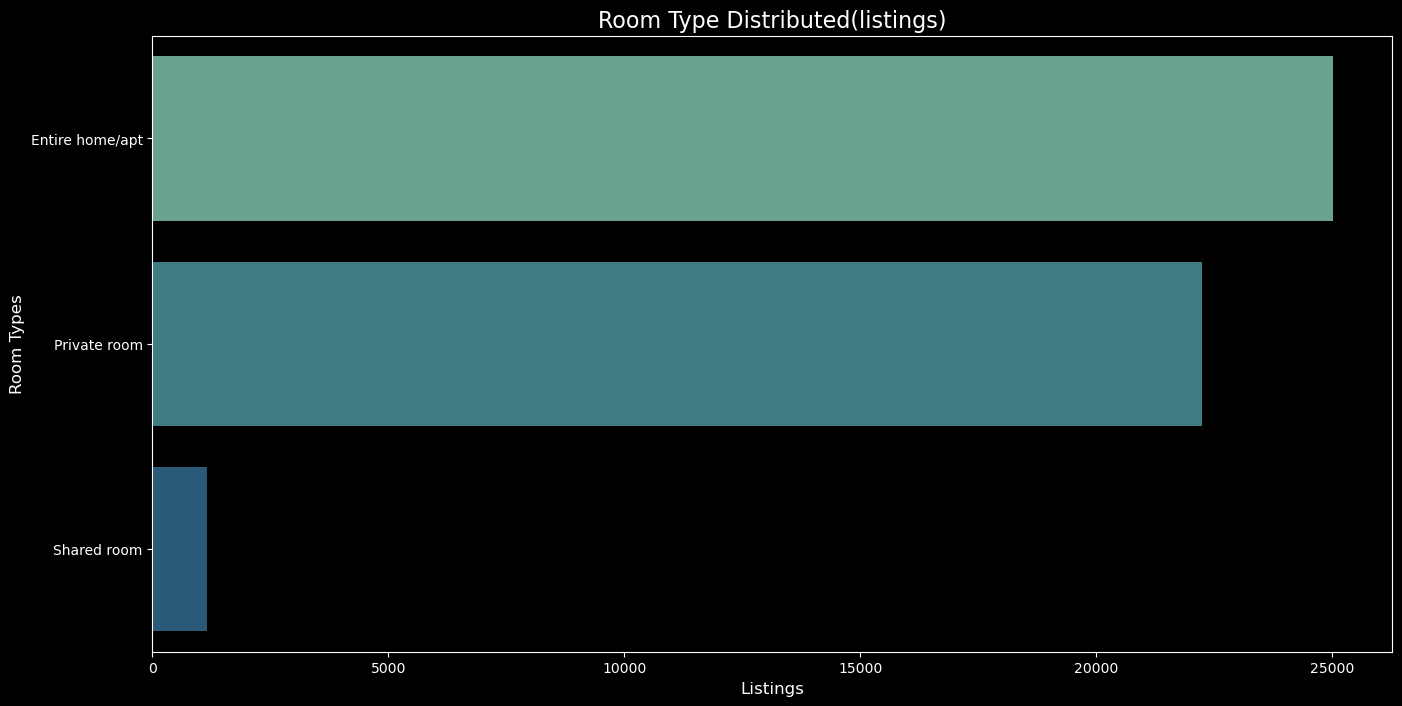

In [41]:
plt.figure(figsize=(16,8))
df_rooms=df_filtered.groupby("room_type")["room_type"].count()
df_rooms

sb.barplot(y=df_rooms.index,x=df_rooms.values,palette="crest")
plt.ylabel("Room Types",fontsize=12)
plt.xlabel("Listings",fontsize=12)
plt.title("Room Type Distributed(listings)",fontsize=16)

### **Insights**: This shows that Entire home/apartment listings dominate the Airbnb market, followed by Private rooms, while Shared rooms make up only a small portion of total listings. **This suggests that most hosts and customers prefer more private accommodation options.**

### **=>Room type with more demand**
demand= Avg(Reviews_per_month)

C:\Users\shaza\AppData\Local\Temp\ipykernel_22968\2921272067.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart=sb.barplot(


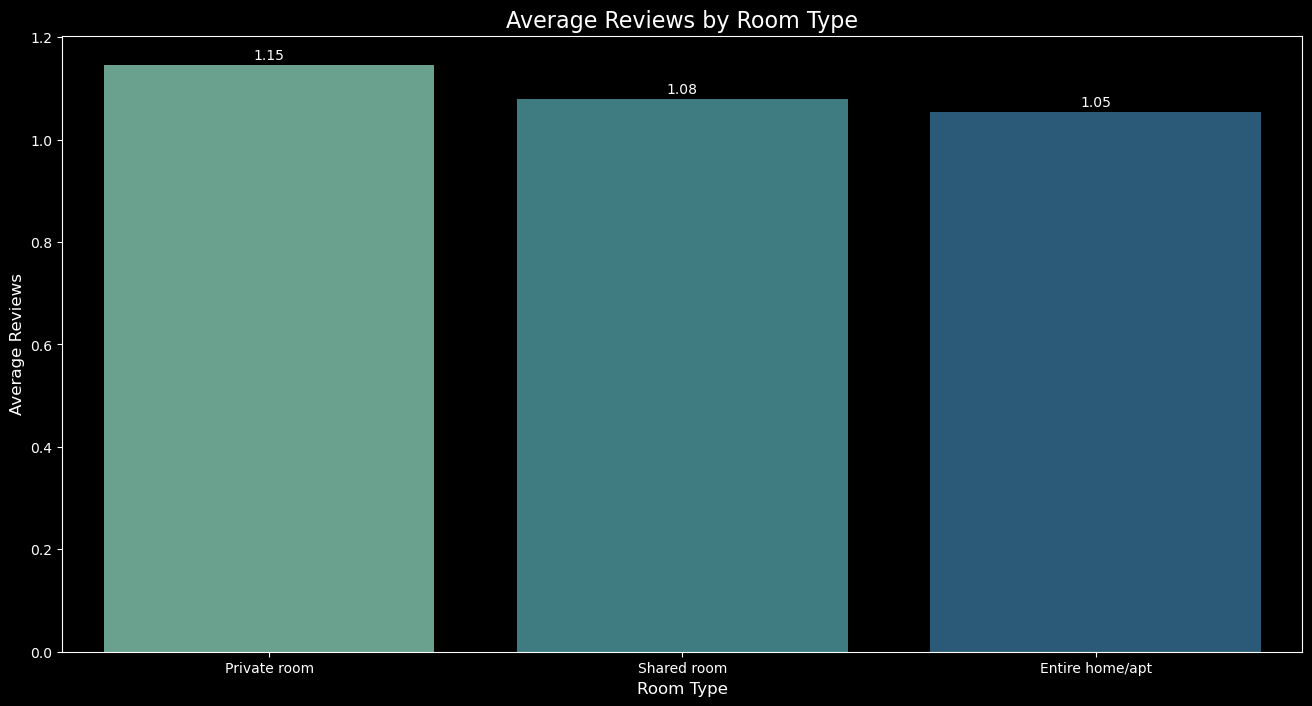

In [42]:
df_room = df_filtered.groupby("room_type").agg(
    avg_reviews=("reviews_per_month", "mean")
)

df_room = df_room.sort_values(by="avg_reviews", ascending=False)


plt.figure(figsize=(16,8))

chart=sb.barplot(
    data=df_room,
    x=df_room.index,
    y="avg_reviews",
   palette="crest"
   
)
for bar in chart.containers:
     chart.bar_label(bar,fmt='%.2f', padding=2)
    

plt.title("Average Reviews by Room Type",fontsize=16)
plt.xlabel("Room Type",fontsize=12)
plt.ylabel("Average Reviews",fontsize=12)

plt.show()

### **Insights:** Despite having lower supply than the Entire home/apt, private room generate the highest review activity, suggesting stronger guest engagement.

In [43]:
df_filtered.groupby("room_type")["price"].agg(
    ["mean","median"]
)

,mean,median
room_type,,
Entire home/apt,189.100272,160.0
Private room,83.394747,70.0
Shared room,64.203301,45.0


### **As expected**, Entire homes command premium pricing, while private and shared rooms compete through affordability.

In [44]:
df_room_price_rev=df_filtered.groupby("room_type").agg(
    avg_price=("price","mean"),
    avg_reviews=("reviews_per_month","mean"),
    listing=("price","count")
)
df_room_price_rev

,avg_price,avg_reviews,listing
room_type,,,
Entire home/apt,189.100272,1.053977,25022
Private room,83.394747,1.145675,22237
Shared room,64.203301,1.079983,1151


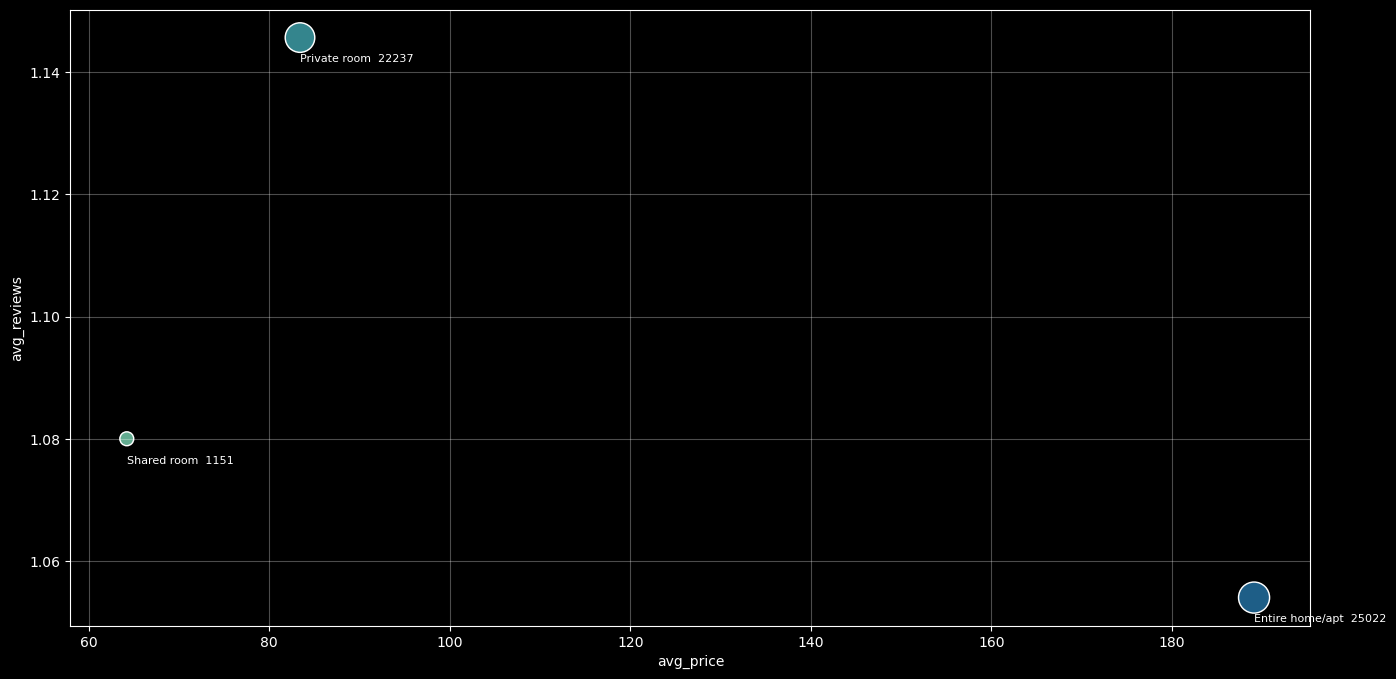

In [45]:
plt.figure(figsize=(16,8))
sb.scatterplot(
    data=df_room_price_rev,
    x="avg_price",
    y="avg_reviews",
    size="listing",
    hue=df_room_price_rev.index,
    palette="crest_r",
    sizes=(100,500)
)
plt.grid(alpha=0.3)
plt.legend().set_visible(False)
for i,item in enumerate(df_room_price_rev.index):
    plt.text(df_room_price_rev["avg_price"].iloc[i],df_room_price_rev["avg_reviews"].iloc[i]-0.004,
             f"{df_room_price_rev.index[i]}  {df_room_price_rev["listing"].iloc[i]}",fontsize=8)

### **Insight:** Private rooms generate the highest customer engagement despite moderate pricing, suggesting that guests prefer a balance between affordability and privacy. Entire homes command premium prices but show slightly lower review activity, while shared rooms attract the low engagement despite being the most affordable option.

### **Business Recommendation:** Hosts seeking higher occupancy should prioritize private-room listings, as they appear to offer the strongest balance between demand and pricing. Premium-focused investors may target entire-home listings, while shared rooms may require additional factors beyond price to attract demand

### **Analysis based on Neighbourhood for Room types**

In [46]:
df_room_area=pd.pivot_table(
    data=df_filtered,
    index=["neighbourhood_group","room_type"],

    values=["price","reviews_per_month"],
    aggfunc="mean"
)
df_room_area["listings"]=df_filtered.groupby(["neighbourhood_group","room_type"])["price"].count()
df_room_area

price  reviews_per_month  listings
neighbourhood_group room_type                                               
Bronx               Entire home/apt  125.198413           1.829577       378
                    Private room      63.147692           1.319492       650
                    Shared room       47.254237           0.984576        59
Brooklyn            Entire home/apt  165.409283           1.131571      9480
                    Private room      72.127017           0.991364     10101
                    Shared room       50.773723           0.754769       411
Manhattan           Entire home/apt  216.958311           0.869240     12905
                    Private room     106.548424           1.150018      7930
                    Shared room       84.085954           1.335031       477
Queens              Entire home/apt  140.808816           1.641131      2087
                    Private room      67.757720           1.548432      3368
                    Shared room       49.312821           1.186103       195
Staten Island       Entire home/apt  131.087209           1.809070       172
                    Private room      62.292553           1.437074       188
                    Shared room       57.444444           0.740000         9

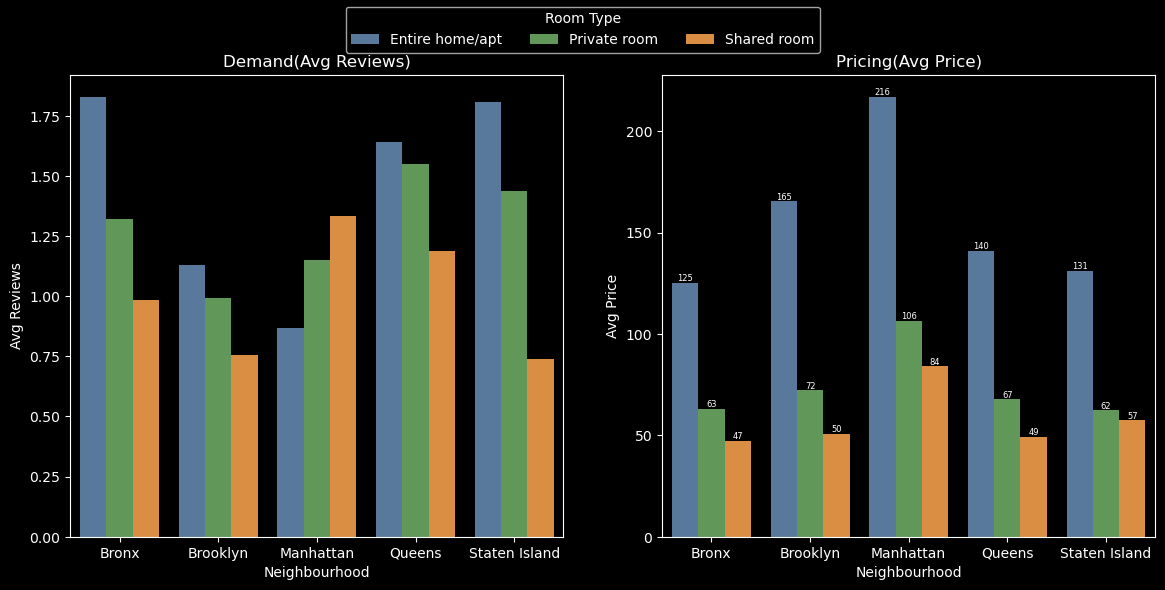

In [47]:
palette= [
   "#4E79A7",  # Budget - Blue
    "#59A14F",  # Standard - Green
    "#F28E2B"] 
fig,ax=plt.subplots(1,2,figsize=(14,6))
sb.barplot(
    data=df_room_area,
    x="neighbourhood_group",
    y="reviews_per_month",
    hue="room_type",
    palette=palette,
    ax=ax[0]

)
ax[0].set_title("Demand(Avg Reviews)")
ax[0].set_xlabel("Neighbourhood")
ax[0].set_ylabel("Avg Reviews")
handles,labels=ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Room Type",
    loc='upper center',
    ncol=3,
    frameon=True,
    
)
ax[0].legend().remove()

chart=sb.barplot(
    data=df_room_area,
    x="neighbourhood_group",
    y="price",
    hue="room_type",
    palette=palette,
    ax=ax[1]
)
ax[1].set_title("Pricing(Avg Price)")
ax[1].set_xlabel("Neighbourhood")
ax[1].set_ylabel("Avg Price")
ax[1].legend().remove()
for container in chart.containers:
    chart.bar_label(container,fmt="%d",fontsize=6)


 ### **Insights**: Demand patterns vary across Boroughs. Entire-Room generate thehighest review activity in Bronx, Brooklyn, Queens and Stalen Island, While in Manhattan Shared room had the upper hand. In Manhattan, Entire room have the highest avg price(~217) but lower review activity than Shared and orivate rooms. This also suggest that the pricing can reduce the booking frequency. 
 ### **Business Recommendations:** Property Manager should align room type strategy with local markets rather han applying a same approach in all cities. Entire Homes are suitable for maximizing revenue in high-value markets, while Private Rooms may provide a better balance between occupancy and pricing.  

# => Does room type influence pricing and customer engagement?(Analaytical)
Ho: Mean price is same across all room types

h1: At least one room type has a different value


In [48]:
from scipy.stats import f_oneway
entire=df_filtered[df_filtered["room_type"]=="Entire home/apt"]["price"]
private=df_filtered[df_filtered["room_type"]=="Private room"]["price"]
shared=df_filtered[df_filtered["room_type"]=="Shared room"]["price"]
f_stat,p_value=f_oneway(entire,private,shared)
print("P_value:",p_value)

P_value: 0.0


In [49]:

entire=df_filtered[df_filtered["room_type"]=="Entire home/apt"]["reviews_per_month"]
private=df_filtered[df_filtered["room_type"]=="Private room"]["reviews_per_month"]
shared=df_filtered[df_filtered["room_type"]=="Shared room"]["reviews_per_month"]
f_stat,p_value=f_oneway(entire,private,shared)

print("P_value:",p_value)

P_value: 3.826874701481203e-09


### **Statistical Validation**: A One-Way ANOVA test was conducted to determine whether average prices differ across room types. The test returned a p-value < 0.05, leading to the rejection of the null hypothesis. This confirms that room type has a statistically significant impact on listing prices and reviews and should be considered a key factor in pricing strategy

# Corelation Heat map

<Axes: >

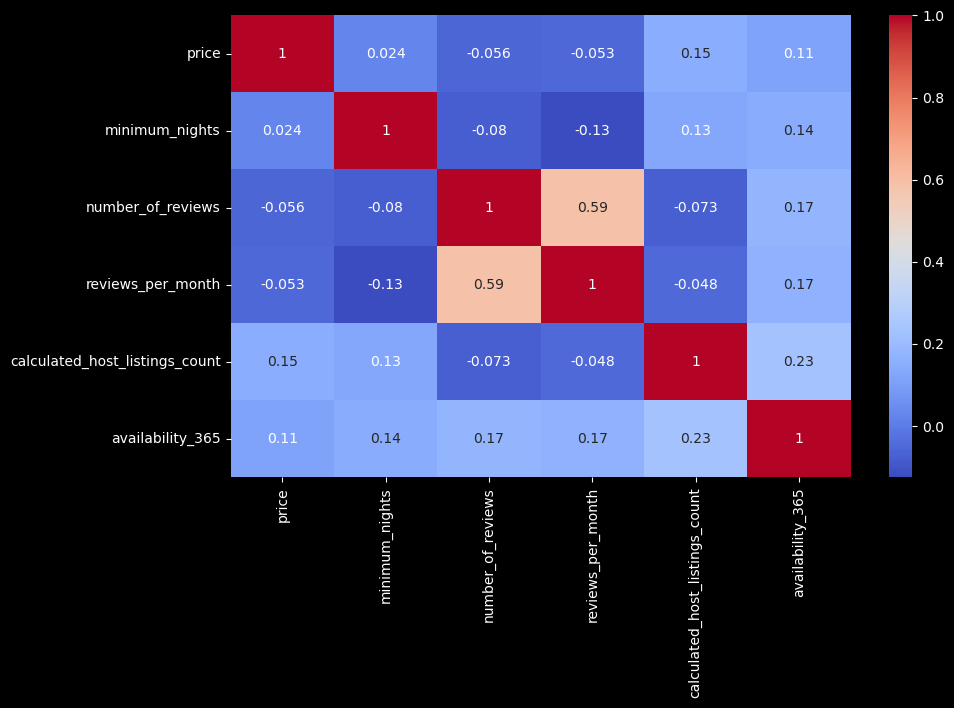

In [50]:
plt.figure(figsize=(10,6))
corr=df_filtered[[
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]].corr()
sb.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

### Number of reviews and reviews per month shows a moderate positive relationship which means listings with more reviews generally continue receiving reviews consistently over time.

 ### =================Airbnb Prediction Model ===========================


The objective of this section is to build machine learning models capable of predicting Airbnb listing prices based on factors such as location, room type, availability, reviews, and host-related information.

In [51]:
#Ml libraries
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [52]:
df_filtered.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'has_review', 'price_category'],
      dtype='object')

In [53]:
#important features related to Airbnb pricing were selected. These features include room type, 
# location coordinates, availability, and host listing information.

X=df_filtered[[
    
    "room_type",
    "minimum_nights",
    "latitude",
    "longitude",
    "availability_365",
    "calculated_host_listings_count"
]]
Y=df_filtered["price"]
X_encoded=pd.get_dummies(X,drop_first=True)
X_train,X_test,Y_train,Y_test= train_test_split(
    X_encoded,
    Y,
    test_size=0.2,
    random_state=42

)

#The dataset was divided into training and testing sets.  
#80% of the data was used for training the model, while 20% was reserved for testing model performance on unseen data.

In [54]:


model=LinearRegression()
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)

In [55]:
#evaluation 
MAE=mean_absolute_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print("Mean absolute Error:",round(MAE,2))
print("R2 Score:",r2)

Mean absolute Error: 53.47
R2 Score: 0.3395619994541178


The Linear Regression model achieved an R² score of approximately 0.34, indicating limited predictive performance. This suggests that Airbnb pricing contains complex and non-linear relationships that cannot be effectively captured by a simple linear model.

## Log Transformation Needed here



Initially, the Linear Regression model showed limited performance because the target variable (price) and the feature number of reviews contained significant skewness and extreme outliers.

To stabilize the distribution and reduce the impact of extreme values, logarithmic transformation was applied to both the target variable and the number of reviews feature before retraining the model.
 

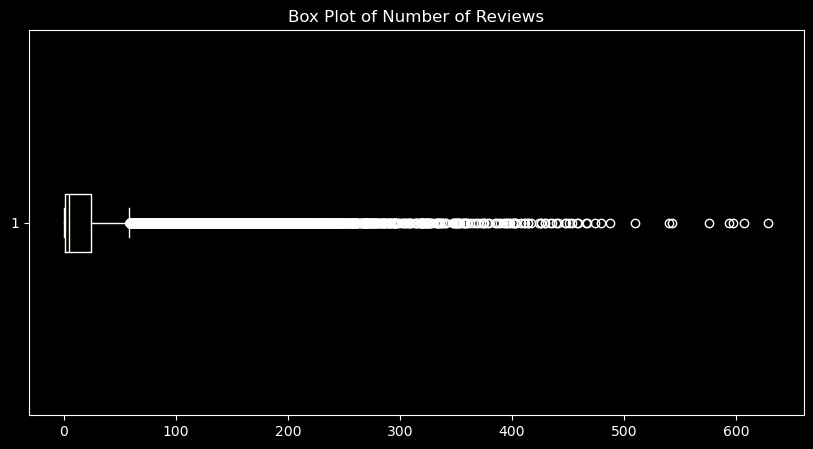

In [56]:
plt.figure(figsize=(10,5))

plt.boxplot(
    df_filtered["number_of_reviews"],
    vert=False
)

plt.title("Box Plot of Number of Reviews")

plt.show()



The box plot shows that the feature contains significant outliers and is highly right-skewed. Most listings have relatively low review counts, while a small number of listings have extremely high reviews.


**To reduce skewness and minimize the impact of extreme values, a logarithmic transformation is applied .**

In [57]:
df_filtered["log_reviews"]=np.log1p(df_filtered["number_of_reviews"])


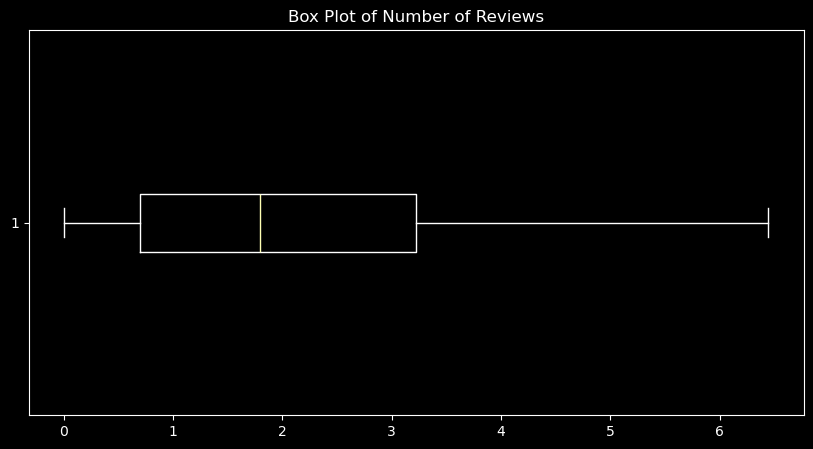

In [58]:
plt.figure(figsize=(10,5))

plt.boxplot(
    df_filtered["log_reviews"],
    vert=False
)

plt.title("Box Plot of Number of Reviews")

plt.show()


**After applying the logarithmic transformation, the distribution of number of reviews became significantly more balanced. The extreme outliers were compressed, reducing skewness.**

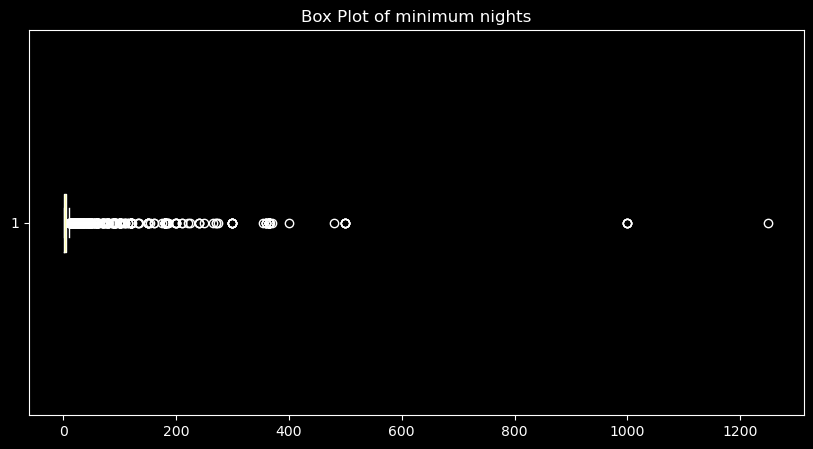

In [59]:
plt.figure(figsize=(10,5))

plt.boxplot(
    df_filtered["minimum_nights"],
    vert=False
)

plt.title("Box Plot of minimum nights")

plt.show()

In [60]:
df_filtered["log_min_nights"]=np.log1p(df_filtered["minimum_nights"])


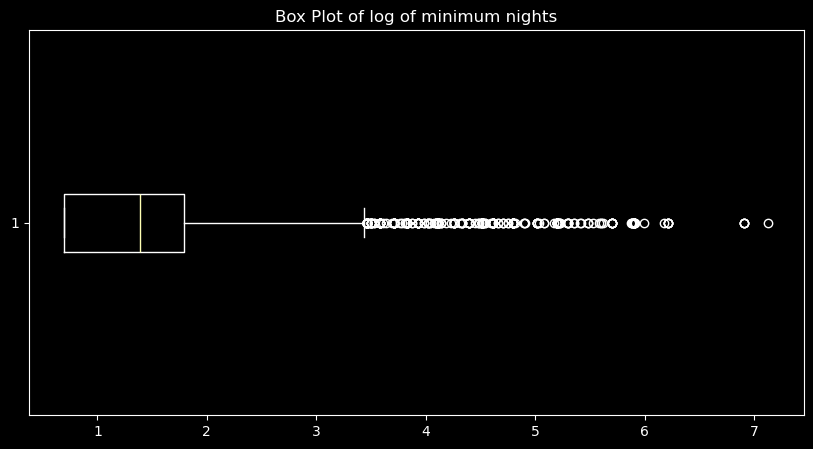

In [61]:
plt.figure(figsize=(10,5))

plt.boxplot(
    df_filtered["log_min_nights"],
    vert=False
)

plt.title("Box Plot of log of minimum nights")

plt.show()


After applying the logarithmic transformation, the distribution of minimum nights became significantly more balanced. The extreme outliers were compressed, reducing skewness.

### Feature Selection

Longitude and latitude were selected instead of neighbourhood and 
#neighbourhood group because they provide more precise location information.

In [62]:
X=df_filtered[[
    
    "room_type",
    "log_min_nights",
    "availability_365",
    "calculated_host_listings_count",
    "longitude",
    "latitude",
    "log_reviews",
    
]]
#applying log on the target variable.
Y=np.log1p(df_filtered["price"])
X_encoded=pd.get_dummies(X,drop_first=True)
X_encoded
X_train,X_test,Y_train,Y_test= train_test_split(
    X_encoded,
    Y,
    test_size=0.2,
    random_state=42

)

In [63]:
df_filtered

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review,price_category,log_reviews,log_min_nights
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,True,Premium,2.302585,0.693147
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,True,High,3.828641,0.693147
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,False,Premium,0.000000,1.386294
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,True,Standard,5.602119,0.693147
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,True,Standard,2.302585,2.397895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaT,0.00,2,9,False,Standard,0.000000,1.098612
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaT,0.00,2,36,False,Budget,0.000000,1.609438
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,0.00,1,27,False,Premium,0.000000,2.397895
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaT,0.00,6,2,False,Standard,0.000000,0.693147


In [64]:

model=LinearRegression()
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)

In [65]:
#evaluation 
MAE=mean_absolute_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print("Mean absolute Error:",round(MAE,2))
print("R2 Score:",r2)

Mean absolute Error: 0.35
R2 Score: 0.5188630628188837


**Model Selection Insight:** Linear Regression was evaluated as a baseline model and achieved an R2 score of 0.52 only, indicating it explained only 52% of the variation in th airbnb price. It is suggested that it is influenced by complex non linear relationships between different characteristics.

# Model 2 Random forest:
 we analyse that between there is no linear strong relationship beteen the price and feature variables, instead it shows weak linear relationships, which shows it depend on complex and non linear relationships.

In [66]:
## for Random forest and Further models we donot need to perfrom log transformation.
X=df_filtered[[
    
    "room_type",
    "minimum_nights",
    "availability_365",
    "calculated_host_listings_count",
    "longitude",
    "latitude",
    "number_of_reviews",
    
]]
#applying log on the target variable because of the skewness adn outliers..
Y=np.log1p(df_filtered["price"])
X_encoded=pd.get_dummies(X,drop_first=True)
X_encoded
X_train,X_test,Y_train,Y_test= train_test_split(
    X_encoded,
    Y,
    test_size=0.2,
    random_state=42

)

In [67]:
from sklearn.ensemble import  RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=99
)

rf_model.fit(X_train,Y_train)
rf_predict=rf_model.predict(X_test)
rf_MAE=mean_absolute_error(Y_test,rf_predict)
rf_r2=r2_score(Y_test,rf_predict)
print(" log Mean absolute error:",round(rf_MAE,2))

print("R2 score:",rf_r2)
#--------score after log-----------
y_actual_test=np.expm1(Y_test)
rf_actual_predict=np.expm1(rf_predict)
rf_actual_mae=mean_absolute_error(y_actual_test,rf_actual_predict)
rf_rmse=np.sqrt(
    mean_squared_error(
        y_actual_test,
        rf_actual_predict
    )
)

print(" Mean absolute error:",round(rf_actual_mae,2))
print("RMSE of random forest:",round(rf_rmse,2))





 log Mean absolute error: 0.31
R2 score: 0.5984058340848655
 Mean absolute error: 45.76
RMSE of random forest: 80.73


In [68]:
#check the tranin and test score
train_score=rf_model.score(X_train,Y_train)
test_score=rf_model.score(X_test,Y_test)
print("train_score:",train_score)
print("test score:",
      test_score)

train_score: 0.5989863540186814
test score: 0.5984058340848655


In [69]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="airbnb_predictor")

address = "Kensington Brooklyn NY"

location = geolocator.geocode(address, timeout=10)

if location:
    
    latitude = location.latitude
    longitude = location.longitude

    print("Address:", location.address)
    print("Latitude:", latitude)
    print("Longitude:", longitude)

else:
    
    print("Address not found")

Address: Kensington, Flatbush, Brooklyn, Kings County, New York, 11218, United States
Latitude: 40.6462149
Longitude: -73.970694


In [70]:

#
room_type="Private room"
minimum_nights=1
host_count=3
availability=365
reviews=10

new_data = pd.DataFrame({
    "room_type": [room_type],
    "minimum_nights": [minimum_nights],
    "availability_365": [availability],
    "calculated_host_listings_count": [host_count],
    "longitude": [longitude],
    "latitude": [latitude],
     "number_of_reviews":[reviews]
    
})
new_data_encoded = pd.get_dummies(new_data)

new_data_encoded = new_data_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

In [71]:
predicted_price = rf_model.predict(new_data_encoded)

actual_price = np.expm1(predicted_price[0])

print("Predicted Airbnb Price: $", round(actual_price,2))

Predicted Airbnb Price: $ 71.69


### Sample Prediction

To demonstrate the practical application of the Random Forest model, a sample Airbnb listing was created using specific listing characteristics such as room type, minimum nights, availability, host listing count, location, and review count. The trained model predicted an estimated nightly price of **$71.69** for this listing.

This example illustrates how the model can be used to estimate Airbnb prices for new listings based on their features.

## Random Forest Conclusion

The Random Forest model demonstrated a significant improvement over the baseline Linear Regression model by effectively capturing non-linear relationships within the data. With an R² score of 0.60 and lower prediction errors, it proved to be a strong predictive model for Airbnb price estimation. To explore whether further performance improvements can be achieved, the next step is to implement and evaluate the XGBoost model.

# XGBOOST Model

XGBoost was implemented as an advanced learning model to further improve prediction accuracy.
By sequentially correcting the errors of previous trees, it effectively captured complex patterns in Airbnb pricing data. The model demonstrated strong performance and was evaluated using cross-validation, training, and testing scores to ensure reliable generalization on unseen data.

In [72]:
from xgboost import XGBRegressor
xgb_model=XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

####cross validation
cv_scores= cross_val_score(
    xgb_model,
    X_train,
    Y_train,
    cv=4,
    scoring="r2"
)
print("average CV mean scores:",round(cv_scores.mean(),2))
xgb_model.fit(X_train,Y_train)
train_pred=xgb_model.predict(X_train)
test_pred=xgb_model.predict(X_test)
#score
train_score=xgb_model.score(X_train,Y_train)
text_score=xgb_model.score(X_test,Y_test)
print("test_score:",test_score)
print("train_score:",train_score)





average CV mean scores: 0.63
test_score: 0.5984058340848655
train_score: 0.6380701889821613


In [73]:
#evaluation
xgb_actual_pred=np.expm1(test_pred)
xgb_mae=mean_absolute_error(
    y_actual_test,xgb_actual_pred
)
xgb_rmse=np.sqrt(
    mean_squared_error(
        y_actual_test,
        xgb_actual_pred
    )
)
xgb_r2=r2_score(
    Y_test,
    test_pred

)
print(" Mean absolute error fo xgbbost:",round(xgb_mae,2))
print("RMSE:", round(xgb_rmse,2))

print("R2 Score:", round(xgb_r2,2))

 Mean absolute error fo xgbbost: 43.57
RMSE: 76.89
R2 Score: 0.63


XGBoost model shows solid generalization with small gap between train, test, and cross-validation scores:

* **MAE:** 43.57
* **RMSE:** 76.89
* **R2 Score:** 0.63 (Matches the average CV score of 0.63)

Next, we will perform **Hyperparameter Tuning** to further reduce the error metrics and optimize performance.


## Hyperparameter tuning

To improve further, We will now use GridSearchCV to find the optimal XGboost parameters. This tests multiple combinations and picks the best one using cross-validation.

In [74]:
from sklearn.model_selection import GridSearchCV
xgb_model=XGBRegressor(
    random_state=42
)
## Hyperparamter grid
param_grid={
    "n_estimators":[100,200],
    "max_depth":[3,4,5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
#grid search
grid_search=GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(
    X_train,Y_train
)
print("best parameters:")
print(grid_search.best_params_)
print("best cross validation score:",round(grid_search.best_score_,2))
xgb_model=grid_search.best_estimator_
xgb_model_predict=xgb_model.predict(X_test)
y_actual_test=np.expm1(Y_test)

xgb_actual_pred=np.expm1(xgb_model_predict)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
best cross validation score: 0.64


In [75]:
#evaluation
xgb_mae= mean_absolute_error(y_actual_test, xgb_actual_pred)
Xgb_rmse=np.sqrt(
    mean_squared_error(
        y_actual_test,xgb_actual_pred
    )
)
xgb_r2_score=r2_score(
    Y_test,
    xgb_model_predict
)
print("The MAE value:",round(xgb_mae,2))
print("The RMSE value:",round(Xgb_rmse,2))
print("R2 score is:",round(xgb_r2_score,2))

The MAE value: 42.36
The RMSE value: 74.14
R2 score is: 0.65


### Hyperparameter tuning improved the XGBoost model's predictive performance, reducing prediction errors and increasing the R² score

In [76]:

#address is above mentioned

#
room_type="Private room"
minimum_nights=1
host_count=3
availability=365
reviews=10
\
new_data = pd.DataFrame({
    "room_type": [room_type],
    "minimum_nights": [minimum_nights],
    "availability_365": [availability],
    "calculated_host_listings_count": [host_count],
    "longitude": [longitude],
    "latitude": [latitude],
     "number_of_reviews":[reviews]
    
})
new_data_encoded = pd.get_dummies(new_data)

new_data_encoded = new_data_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)
predicted_price = xgb_model.predict(new_data_encoded)

actual_price = np.expm1(predicted_price[0])

print("Predicted Airbnb Price: $", round(actual_price,2))

Predicted Airbnb Price: $ 77.86


#### To demonstrate the practical application of the final model, a sample Airbnb listing was created using specific property characteristics, including room type, minimum nights, availability, host listing count, location coordinates, and review count.

### After applying the same preprocessing steps used during training, the tuned XGBoost model predicted an estimated nightly Airbnb price of **77.86**.

                          Feature  Importance
6          room_type_Private room    0.603037
7           room_type_Shared room    0.312890
3                       longitude    0.026122
4                        latitude    0.017794
1                availability_365    0.011824
0                  minimum_nights    0.011576
2  calculated_host_listings_count    0.008701
5               number_of_reviews    0.008056


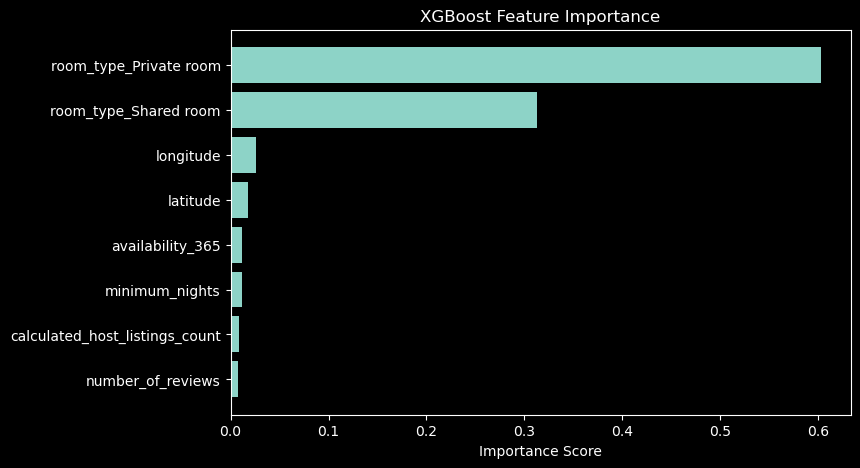

In [77]:


feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(8,5))
chart=plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

    
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

### **Feature Importance:** Room type is by far the strongest driver of Airbnb prices, accounting for over 90% of the model's predictive importance. Location factors (latitude and longitude) have a smaller but noticeable influence, while availability, minimum stay requirements, host portfolio size, and review volume contribute relatively little to pricing decisions.